In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jaidalmotra/weed-detection")

print("Path to dataset files:", path)

100%|██████████| 156M/156M [00:01<00:00, 105MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jaidalmotra/weed-detection/versions/1


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.callbacks import TensorBoard
import pickle
from tensorflow.keras.models import Model
import time
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import cv2
import random
from tensorflow.keras.applications import ResNet152V2
import pathlib
from pathlib import Path

In [ ]:
train_directory="/root/.cache/kagglehub/datasets/jaidalmotra/weed-detection/versions/1/train/"
test_directory ="/root/.cache/kagglehub/datasets/jaidalmotra/weed-detection/versions/1/test"
train_dataen = ImageDataGenerator(rescale=1./255,
                                  rotation_range=30,
                                  width_shift_range=1.0,
                                  height_shift_range=1.0,
                                  horizontal_flip=True,
                                  vertical_flip=True,validation_split=0.2)
validaion_dataen=ImageDataGenerator(rescale=1./255, validation_split=0.2)
test_datagen=ImageDataGenerator(rescale=1./255)

In [ ]:
from typing_extensions import Counter
Counter([Path(file).name.split("_")[0] for file in os.listdir(train_directory)])

Counter({'ridderzuring': 825, 'Rumex-obtusifolius-L': 836, '': 1})

In [ ]:
import os
from pathlib import Path

def organize_files(directory):
    """
    Organizes files and directories in the given directory into 'ridderzuring' and 'Rumex_obtusifolius' folders.

    Parameters:
        directory (str): Path to the directory to be organized.

    Returns:
        None
    """
    # Create target directories
    ridderzuring_directory = Path(directory) / "ridderzuring"
    Rumex_obtusifolius_directory = Path(directory) / "Rumex_obtusifolius"

    os.makedirs(ridderzuring_directory, exist_ok=True)
    os.makedirs(Rumex_obtusifolius_directory, exist_ok=True)

    # Iterate through all files and subdirectories in the directory
    for file in os.listdir(directory):
        target_dir = None

        # Determine the target directory based on file name prefix
        if file.split("_")[0] == "ridderzuring":
            target_dir = ridderzuring_directory
        elif file.split("_")[0] == "Rumex":
            target_dir = Rumex_obtusifolius_directory
        else:
            continue  # Skip files/directories that don't match the criteria

        source_path = os.path.join(directory, file)
        target_path = os.path.join(target_dir, file)

        # Handle directories
        if os.path.isdir(source_path) and source_path != str(target_dir):
            # Move contents of the source directory to the target directory
            for item in os.listdir(source_path):
                item_source_path = os.path.join(source_path, item)
                item_target_path = os.path.join(target_path, item)
                os.rename(item_source_path, item_target_path)
            # Remove the original directory after moving files
            os.rmdir(source_path)

        # Handle individual files
        elif os.path.isfile(source_path):
            os.rename(source_path, target_path)



In [ ]:
organize_files(train_directory)

In [ ]:
organize_files(test_directory)

In [ ]:
train_data= train_dataen.flow_from_directory(train_directory,
                                            class_mode="categorical",
                                            batch_size=32,
                                             target_size=(224,224))
validation_data=validaion_dataen.flow_from_directory(train_directory,
                                            class_mode="categorical",
                                            batch_size=32,
                                                     subset="validation"
                                                     ,target_size=(224,224))
test_data=test_datagen.flow_from_directory(test_directory,
                                            class_mode="categorical",
                                           target_size=(224,224),
                                            batch_size=32)

Found 825 images belonging to 2 classes.
Found 165 images belonging to 2 classes.
Found 245 images belonging to 2 classes.


array([[[ 57,  61,  24],
        [ 65,  69,  32],
        [ 80,  84,  47],
        ...,
        [140, 141, 107],
        [130, 132,  95],
        [121, 123,  86]],

       [[ 62,  66,  29],
        [ 68,  72,  35],
        [ 81,  85,  48],
        ...,
        [135, 136, 102],
        [126, 128,  91],
        [119, 121,  84]],

       [[ 68,  72,  35],
        [ 73,  77,  40],
        [ 83,  87,  50],
        ...,
        [130, 132,  95],
        [122, 124,  87],
        [116, 118,  81]],

       ...,

       [[139, 135,  98],
        [136, 132,  95],
        [132, 128,  91],
        ...,
        [ 54,  56,  17],
        [ 57,  59,  20],
        [ 62,  64,  25]],

       [[137, 133,  96],
        [130, 126,  89],
        [121, 117,  80],
        ...,
        [ 63,  65,  26],
        [ 64,  66,  27],
        [ 69,  71,  32]],

       [[134, 130,  93],
        [125, 121,  84],
        [113, 109,  72],
        ...,
        [ 68,  70,  31],
        [ 66,  68,  29],
        [ 70,  72,  33]]], dtype=uint8)
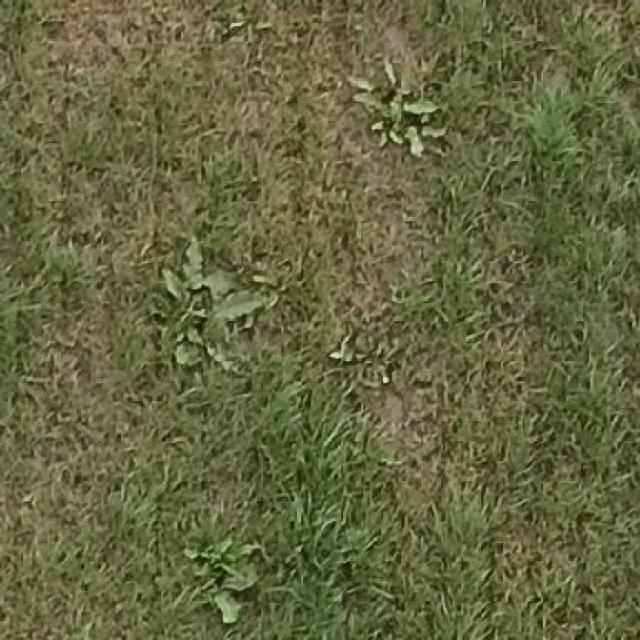

In [ ]:
image=Image.open("/root/.cache/kagglehub/datasets/jaidalmotra/weed-detection/versions/1/train/Rumex-obtusifolius-L_0004_jpg.rf.abe91960d17d8aeebb5261b53296123b.jpg")
image_shape =np.array(image)
image_shape

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet152V2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Load pre-trained ResNet152V2 (excluding the top classification layer)
base_model = ResNet152V2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the layers in the base model
for layer in base_model.layers:
    layer.trainable = False

# Add new classification layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Add a global average pooling layer
x = Dense(1024, activation='relu')(x)  # Add a fully-connected layer
predictions = Dense(2, activation='softmax')(x)  # Output layer with softmax

# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(train_data, epochs=3, validation_data=validation_data)

Epoch 1/3
26/26 [==============================] - 358s 14s/step - loss: 0.0214 - accuracy: 0.9903 - val_loss: 0.0000e+00 - val_accuracy: 1.0000
Epoch 2/3
26/26 [==============================] - 345s 13s/step - loss: 0.0000e+00 - accuracy: 1.0000 - val_loss: 0.0000e+00 - val_accuracy: 1.0000
Epoch 3/3
26/26 [==============================] - 346s 13s/step - loss: 0.0000e+00 - accuracy: 1.0000 - val_loss: 0.0000e+00 - val_accuracy: 1.0000


In [ ]:
model.summary()

In [ ]:
model.predict(test_data)

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 941ms/step


array([[0.08309172, 0.9169083 ],
       [0.08402625, 0.9159738 ],
       [0.07720104, 0.922799  ],
       [0.07331718, 0.9266828 ],
       [0.06559724, 0.93440276],
       [0.09442014, 0.90557986],
       [0.11652776, 0.8834722 ],
       [0.08927049, 0.91072947],
       [0.10543863, 0.89456135],
       [0.08004683, 0.9199532 ],
       [0.0681196 , 0.9318803 ],
       [0.08990657, 0.9100934 ],
       [0.11630938, 0.8836906 ],
       [0.091676  , 0.90832394],
       [0.07393601, 0.926064  ],
       [0.06893294, 0.9310671 ],
       [0.06953222, 0.9304677 ],
       [0.06668447, 0.9333154 ],
       [0.0808508 , 0.91914916],
       [0.10343039, 0.89656955],
       [0.07547341, 0.92452663],
       [0.0989875 , 0.9010124 ],
       [0.09304235, 0.9069576 ],
       [0.09459828, 0.9054017 ],
       [0.07369776, 0.92630213],
       [0.09164508, 0.9083549 ],
       [0.06187353, 0.9381265 ],
       [0.07956079, 0.92043924],
       [0.08634003, 0.91365993],
       [0.07818756, 0.9218125 ],
       [0.

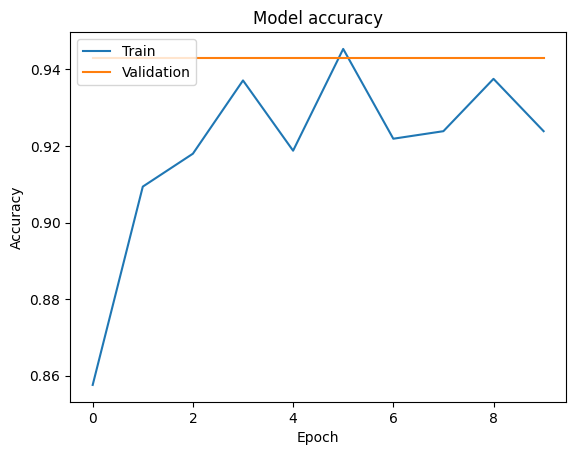

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
model.save("/content/drive/My Drive/weed_t_detection_model.h5")

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [1]:
!apt-get install git

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.11).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.


In [2]:
!git clone https://github.com/darish500/CNN-Neaural-networks.git

Cloning into 'CNN-Neaural-networks'...


In [5]:
!cp /content/weeddetection.ipynb/content/CNN-Neaural-networks/

cp: missing destination file operand after '/content/weeddetection.ipynb/content/CNN-Neaural-networks/'
Try 'cp --help' for more information.
